# Week12 Lab —  Q-Learning with FrozenLake


## Introduction to ~OpenAI gym~ Gymnasium
In this notebook we will be using [gymnasium](https://github.com/Farama-Foundation/Gymnasium), a great toolkit for developing and comparing Reinforcement Learning algorithms. It provides many environments for your learning *agents* to interact with. 

If Gymnasium is not installed, run:
```python
!pip install gymnasium
```

In this lab, let's use Q-learning to train an agent to play FrozenLake.


## 0. Install and Import Libraries
- `gymnasium`: provides the FrozenLake environment.
- `numpy`: stores and updates the Q-table.
- `matplotlib`: plots training results.

In [ ]:
# If needed, uncomment the following line:
# !pip install gymnasium

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


## 1. Load FrozenLake Environment

You can check the documentation for FrozenLake here:  
https://gymnasium.farama.org/environments/toy_text/frozen_lake/

*Note: We use is_slippery=False as a demo* 
```python
is_slippery=False
```
This makes the environment deterministic. If the agent chooses right, it really moves right.  

Later, you can set `is_slippery=True` to show stochastic transitions,meaning the agent’s movement is uncertain.


In [93]:
env = gym.make("FrozenLake-v1", is_slippery=False)

num_states = env.observation_space.n
num_actions = env.action_space.n

# Action names for readability.
action_names = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

possible_actions = [np.arange(num_actions) for state in range(num_states)]

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
for action_id, action_name in action_names.items():
    print(action_id, "=", action_name)


Observation space: Discrete(16)
Action space: Discrete(4)
0 = Left
1 = Down
2 = Right
3 = Up


## 2. Set Hyperparameters

1. Initial Learning Rate: ```alpha = 0.05```
2. Discount Factor: ```gamma```
- \(\gamma=0\): only care about immediate reward.
- \(\gamma\approx1\): care strongly about future reward.
3. ```epsilon``` controls exploration, the agent will chooses a random action ```epsilon``` of the time; and chooses the action with the highest Q-value ```1-epsilon``` of the time.

In [ ]:
num_episodes = 5000  
alpha = 0.2      
gamma = 0.95 
epsilon = 0.5     # initial exploration rate

print("maximum episode steps:", env.spec.max_episode_steps) 

maximum episode steps: 100


## 3. The Q-Learning Update Formula

$$Target = r+\gamma\max_{a'}Q(s',a')$$

$$Q(s,a) \leftarrow Q(s,a)+\alpha\left[Target-Q(s,a)\right]$$

Where:
- $Q(s,a)$: old estimate
- $r$: immediate reward
- $s'$: next state
- $max_{a'}Q(s',a')$: best estimated future value from the next state
- $alpha$: learning rate
- $gamma$: discount factor




In [95]:
def update_Q_values(Q_values, state, action, reward, next_state, alpha, gamma):
    next_value = np.max(Q_values[next_state])

    Target =  reward + gamma * next_value
    Q_values[state, action] = Q_values[state, action] - alpha * (Q_values[state, action]-Target) 

    return Q_values

## 4. Train the Agent

1. At the beginning, the agent knows nothing. So we initialize every Q-value to 0. 
2. The exploratory behavior policy based on epsilon
3. When taking a new step, we can get reward or next_sate by call function: 
    ```next_state, reward, terminated, truncated, info = env.step(action)```
    1. terminated = True (state = Hole or state = Goal) 
    2. truncated means the episode was stopped by an outside limit

4. For FrozenLake, an episode ends when the agent reaches a hole or the goal. When this happens, we reset back to the start state so training can continue.
We also record:
- return per episode
- steps per episode


In [ ]:
# Initialize Q-table before training
Q_values = np.zeros((env.observation_space.n, env.action_space.n))

episode_returns = [] # Store total reward for each episode.
episode_steps = []   # Store number of steps for each episode.
success_rate = []# Store success indicator for each episode.


# Run the Q-learning algorithm.
for iteration in range(num_episodes):
    state,info = env.reset()
    done = False
    episode_return = 0
    episode_step = 0

    for step in range(env.spec.max_episode_steps): #100 by default
        
        # 1. Choose action with Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q_values[state]))

        # 2. Take one step and observe next state, reward, and done.
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q_values[next_state])
        
        # 3. Update Q-table, using the textbook-style update
        Q_values = update_Q_values(Q_values, state, action, reward, next_state, alpha, gamma)
        state = next_state

        # 4. Track episode metrics
        episode_return += reward
        episode_step += 1
    
        # If the episode ended, reset to the start state for the next episode.
        if done:
            episode_returns.append(episode_return)
            episode_steps.append(episode_step)
            success_rate.append(int(episode_return > 0))
            break
        
    # Print progress every 1000 episodes.
    if (iteration + 1) % 1000 == 0:
        recent_success = np.mean(success_rate[-1000:]) * 100
        print("Episode:", iteration + 1,
              "| Reward:", episode_return,
              "| Steps:", episode_step,
              "| Recent success rate:", f"{recent_success:.1f}%")

print("Training finished.")
print("Number of completed episodes:", len(episode_returns))

Episode: 1000 | Reward: 1 | Steps: 20 | Recent success rate: 32.8%
Episode: 2000 | Reward: 1 | Steps: 7 | Recent success rate: 42.2%
Episode: 3000 | Reward: 0 | Steps: 7 | Recent success rate: 42.1%
Episode: 4000 | Reward: 1 | Steps: 6 | Recent success rate: 42.3%
Episode: 5000 | Reward: 1 | Steps: 7 | Recent success rate: 39.8%
Training finished.
Number of completed episodes: 5000


## 5. Inspect the Learned Q-Table

After training, the Q-table contains learned estimates of long-term action values.

Each row is one state.  
Each column is one action.


In [ ]:
np.set_printoptions(precision=3, suppress=True)

print("Learned Q-table:")
print(Q_values)

best_actions = np.argmax(Q_values, axis=1)

best_action_names = np.array([action_names[a] for a in best_actions]).reshape(4, 4)
print(best_action_names.reshape(4, 4))

Learned Q-table:
[[0.735 0.774 0.774 0.735]
 [0.735 0.    0.815 0.774]
 [0.774 0.857 0.774 0.815]
 [0.815 0.    0.765 0.762]
 [0.774 0.815 0.    0.735]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.    0.815]
 [0.    0.    0.    0.   ]
 [0.815 0.    0.857 0.774]
 [0.815 0.902 0.902 0.   ]
 [0.857 0.95  0.    0.857]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.95  0.857]
 [0.902 0.95  1.    0.902]
 [0.    0.    0.    0.   ]]

Best action for each state:
[1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]

Best actions reshaped as 4x4 grid:
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]
[['Down' 'Right' 'Down' 'Left']
 ['Down' 'Left' 'Down' 'Left']
 ['Right' 'Down' 'Down' 'Left']
 ['Left' 'Right' 'Right' 'Left']]


## 6. Test the Learned Policy

Now we use the greedy policy derived from the Q-table.

```python
action = np.argmax(Q_values[state])
```


In [101]:
def run_one_episode(env, Q_values, seed=42, max_steps=100):
    state, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    steps = 0
    path = [state]

    while not done and steps < max_steps:
        action = np.argmax(Q_values[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        total_reward += reward
        steps += 1
        state = next_state
        path.append(state)

    return total_reward, steps, path


test_return, test_steps, test_path = run_one_episode(env, Q_values)

print("Test return:", test_return)
print("Test steps:", test_steps)
print("Path:", test_path)
print("Path as grid positions:", [(s // 4, s % 4) for s in test_path])

Test return: 1
Test steps: 6
Path: [0, 4, 8, 9, 13, 14, 15]
Path as grid positions: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)]


## 7. Plot the Generated Episode

The yellow cells show the visited path.

The green arrows show the movements made by the agent during the generated episode.

Blue cells are holes, and the green cell is the goal.


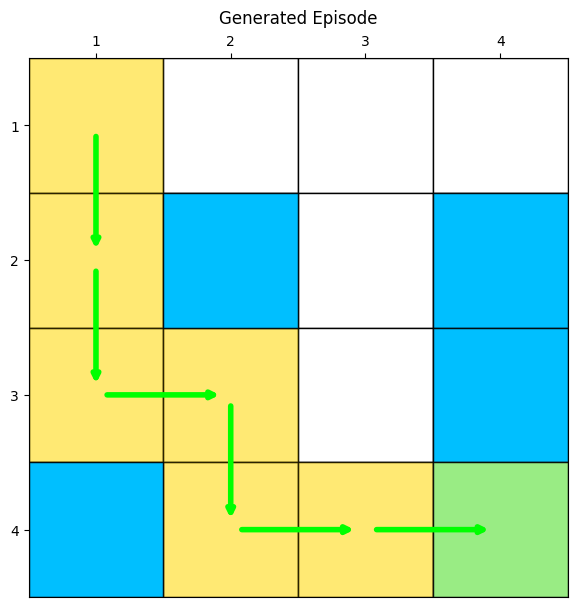

In [103]:

from matplotlib.patches import Rectangle


def plot_generated_episode(env, states_df, transitions_df, title="Generated Episode"):
    """Plot one generated FrozenLake episode on the grid."""
    desc = env.unwrapped.desc.astype(str)
    nrow, ncol = desc.shape

    fig, ax = plt.subplots(figsize=(7, 7))

    # 1. Draw base map
    for r in range(nrow):
        for c in range(ncol):
            tile = desc[r, c]

            if tile == "H":
                facecolor = "deepskyblue"     # hole
            elif tile == "G":
                facecolor = "lightgreen"      # goal
            else:
                facecolor = "white"           # start or frozen tile

            ax.add_patch(
                Rectangle(
                    (c, r),
                    1,
                    1,
                    facecolor=facecolor,
                    edgecolor="black",
                    linewidth=1
                )
            )

    # 2. Highlight visited cells
    for _, row in states_df.iterrows():
        r = int(row["row"]) - 1
        c = int(row["col"]) - 1

        ax.add_patch(
            Rectangle(
                (c, r),
                1,
                1,
                facecolor="gold",
                alpha=0.55,
                edgecolor="black",
                linewidth=1
            )
        )

    # 3. Re-draw terminal cells on top, so holes and goal remain clear
    for r in range(nrow):
        for c in range(ncol):
            tile = desc[r, c]
            if tile == "H":
                ax.add_patch(
                    Rectangle((c, r), 1, 1, facecolor="deepskyblue", alpha=0.85,
                              edgecolor="black", linewidth=1)
                )
            elif tile == "G":
                ax.add_patch(
                    Rectangle((c, r), 1, 1, facecolor="lightgreen", alpha=0.85,
                              edgecolor="black", linewidth=1)
                )

    # 4. Draw movement arrows
    for _, row in transitions_df.iterrows():
        x1 = float(row["from_col"]) - 0.5
        y1 = float(row["from_row"]) - 0.5
        x2 = float(row["to_col"]) - 0.5
        y2 = float(row["to_row"]) - 0.5

        # If the agent hits a wall, the state may not change. Mark it as a dot.
        if x1 == x2 and y1 == y2:
            ax.plot(x1, y1, marker="o", markersize=9, color="lime")
            continue

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=4,
                color="lime",
                shrinkA=8,
                shrinkB=8
            )
        )

    # 5. Add grid labels like the teaching figure
    ax.set_xticks(np.arange(ncol) + 0.5)
    ax.set_yticks(np.arange(nrow) + 0.5)
    ax.set_xticklabels(np.arange(1, ncol + 1))
    ax.set_yticklabels(np.arange(1, nrow + 1))
    ax.xaxis.tick_top()

    ax.set_xlim(0, ncol)
    ax.set_ylim(nrow, 0)
    ax.set_aspect("equal")
    ax.set_title(title, pad=25)
    ax.grid(False)

    plt.show()


plot_generated_episode(env, states_df, transitions_df)



## 8. Optional: Render the Environment

Rendering may work differently depending on where you run the notebook.

If you want to render each step visually, create the environment with:

```python
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
```

Then run one episode.

This works better on a local machine than in some cloud notebook environments.


In [104]:
# Optional local rendering example:
# env_render = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
# state, info = env_render.reset()
# done = False
#
# while not done:
#     action = np.argmax(Q_values[state])
#     next_state, reward, terminated, truncated, info = env_render.step(action)
#     done = terminated or truncated
#     state = next_state
#
# env_render.close()


## Discussion Questions

1. Why do we need future reward instead of only immediate reward?
2. What happens if \(\epsilon\) is too high?
3. What happens if \(\epsilon\) is too low?
4. What happens if \(\gamma=0\)?
5. Why does Q-table work for FrozenLake?
6. Why might Q-table fail for image-based games such as Atari or Mario?
7. How is Q-learning different from simply following the highest immediate reward?
8. What if you change 
    ```python
    is_slippery=False
    ```
    to:

    ```python
    is_slippery=True
    ```
9. When the environment becomes stochastic
    - Does training become harder?
    - Do you need more episodes?
    - Does the learned policy change?